In [2]:
import pandas as pd 
import glob 
import numpy as np
import os

In [2]:
df = pd.read_csv("data/Misdrijf data/Geregistreerde misdrijven month 1.csv", sep=";"
)
df.head()  




,Wijk,Totaal misdrijven
0,Haarlemmerbuurt,80
1,Jordaan,129
2,Grachtengordel-West,78
3,Burgwallen-Nieuwe Zijde,546
4,Burgwallen-Oude Zijde,402


In [ ]:
df

In [3]:
path = "C:/Users/Emma Hendriks/Documents/GitHub/Spatial-data-science/data/Misdrijf data/"
all_misdrijf_files = sorted(glob.glob(path + "*.csv"))

dfs = []

for file in all_misdrijf_files:
    df = pd.read_csv(file, sep=None, engine="python")
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True) 
df_all

,﻿Wijk,Totaal misdrijven
0,Haarlemmerbuurt,75
1,Jordaan,158
2,Grachtengordel-West,78
3,Burgwallen-Nieuwe Zijde,373
4,Burgwallen-Oude Zijde,236
...,...,...
1315,K-buurt,25
1316,Holendrecht,37
1317,Nellestein,20
1318,Reigersbos,31


In [ ]:
df_crime_average_per_year = df_all.groupby('\ufeffWijk')['Totaal misdrijven'].mean().reset_index() 
df_crime_average_per_year.rename(columns={'\ufeffWijk':'Wijk'}, inplace=True) 
df_crime_average_per_year['Totaal misdrijven'] = df_crime_average_per_year['Totaal misdrijven'].round(0)  
df_crime_average_per_year

ik ga nu de tabel ff helemaal goed zetten en fixen  
(kon andere code niet vinden om hierbij te plakken maar begin nu ff met de tabel die we al hadden tus total_table.csv)


In [32]:
df = pd.read_csv("data/total_table.csv")
df

,wijkcode,wijknaam,aantal_lantaarns,Totaal misdrijven,wijkcode_clean,AfstandTotHuisartsenpraktijk_5,AfstandTotHuisartsenpost_9,AfstandTotApotheek_10,AfstandTotZiekenhuis_11,AfstandTotZiekenhuis_15,...,AfstandTotZwembad_93,AfstandTotKunstijsbaan_94,AfstandTotMuseum_95,AfstandTotPodiumkunstenTotaal_99,AfstandTotPoppodium_103,AfstandTotBioscoop_104,AfstandTotSauna_108,AfstandTotZonnebank_109,AfstandTotAttractie_110,AfstandTotBrandweerkazerne_114
0,WK0363AA,Haarlemmerbuurt,885,73.0,wk0363aa,0.5,4.5,0.7,2.0,4.5,...,1.4,6.5,1.2,0.7,2.6,0.9,1.5,0.8,3.3,1.9
1,WK0363AB,Jordaan,1330,150.0,wk0363ab,0.4,3.7,0.5,1.5,3.7,...,0.8,6.8,0.6,0.6,1.5,1.0,1.1,0.8,3.2,0.9
2,WK0363AC,Grachtengordel-West,665,92.0,wk0363ac,0.4,3.9,0.7,1.0,3.9,...,1.2,6.3,0.5,0.5,1.4,1.2,0.6,0.8,3.1,1.3
3,WK0363AD,Burgwallen-Nieuwe Zijde,902,452.0,wk0363ad,0.5,3.7,0.7,0.8,3.7,...,1.6,6.0,0.5,0.8,1.7,1.4,0.5,1.2,2.7,1.7
4,WK0363AE,Burgwallen-Oude Zijde,861,259.0,wk0363ae,0.5,3.2,0.4,1.1,3.2,...,2.1,5.4,0.3,0.5,2.1,1.2,0.5,1.7,2.2,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,WK0363TH,K-buurt,1308,29.0,wk0363th,0.5,4.0,0.8,4.0,4.0,...,2.3,6.3,5.8,2.2,7.6,3.7,4.2,4.3,3.3,1.8
106,WK0363TJ,Holendrecht,1905,40.0,wk0363tj,0.9,1.4,0.9,1.4,1.4,...,2.6,8.1,6.6,2.5,9.1,3.5,6.1,6.4,2.9,2.4
107,WK0363TK,Nellestein,1059,18.0,wk0363tk,0.9,3.5,1.5,3.5,3.5,...,2.7,7.1,5.9,2.6,8.4,4.1,5.0,5.3,2.6,0.6
108,WK0363TL,Reigersbos,1743,37.0,wk0363tl,1.0,2.5,1.0,2.5,2.5,...,3.7,8.7,7.5,3.6,9.8,4.6,6.8,7.1,2.6,2.3


I cleaned the data set of CBS wijken data with the amount of inwoners and oppervlakte per wijk, to make it ready to merge to the final data frame

In [33]:
path = "data/Kerncijfers_2023.csv"  

# 1) find start data
with open(path, "r", encoding="utf-8") as f:
    lines = f.readlines()
start = next(i for i, line in enumerate(lines) if line.strip().startswith('"Onderwerp"'))

# 2)read csv from that row
raw = pd.read_csv(
    path,
    sep=";",
    skiprows=start,
    quotechar='"',
    encoding="utf-8",
    low_memory=False
).set_index("Onderwerp")

# 3) Take the rows needed + transpose
needed = raw.loc[
    [
        "Regioaanduiding|Codering",
        "Regioaanduiding|Soort regio",
        "Bevolking|Aantal inwoners",
        "Oppervlakte|Oppervlakte totaal",
    ]
].T

# 4) rename columns
needed = needed.rename(columns={
    "Regioaanduiding|Codering": "code",
    "Regioaanduiding|Soort regio": "soort_regio",   # Gemeente / Wijk / Buurt
    "Bevolking|Aantal inwoners": "inwoners",
    "Oppervlakte|Oppervlakte totaal": "oppervlakte_ha",
})

# 5) clean
needed["inwoners"] = (
    needed["inwoners"].astype(str).str.replace(" ", "", regex=False)
)
needed["inwoners"] = pd.to_numeric(needed["inwoners"], errors="coerce").astype("Int64")
needed["oppervlakte_ha"] = pd.to_numeric(needed["oppervlakte_ha"], errors="coerce")

# km² oppervlakte
needed["oppervlakte_km2"] = needed["oppervlakte_ha"] / 100

df_final = needed[["code", "soort_regio", "inwoners", "oppervlakte_ha", "oppervlakte_km2"]].dropna(subset=["code"])

# 6) only  wijken (drop buurten + gemeenten)
df_wijken = df_final[df_final["soort_regio"].str.strip() == "Wijk"].copy()

df_wijken

Onderwerp,code,soort_regio,inwoners,oppervlakte_ha,oppervlakte_km2
Haarlemmerbuurt,WK0363AA,Wijk,9135,81.0,0.81
Jordaan,WK0363AB,Wijk,19545,95.0,0.95
Grachtengordel-West,WK0363AC,Wijk,6585,57.0,0.57
Burgwallen-Nieuwe Zijde,WK0363AD,Wijk,4335,73.0,0.73
Burgwallen-Oude Zijde,WK0363AE,Wijk,4565,40.0,0.40
...,...,...,...,...,...
Nellestein,WK0363TK,Wijk,3115,274.0,2.74
Reigersbos,WK0363TL,Wijk,8540,133.0,1.33
Gein,WK0363TM,Wijk,11220,192.0,1.92
Wijk 06 Nieuw-Amsterdam,WK011406,Wijk,4730,1360.0,13.60


Merged the Wijk info to the final data frame

In [34]:
# 0) code cleaning
df["wijkcode"] = df["wijkcode"].astype(str).str.strip().str.upper()
df_wijken["code"] = df_wijken["code"].astype(str).str.strip().str.upper()

# 1) Select columns to merge
cbs_cols = df_wijken[["code", "inwoners", "oppervlakte_ha", "oppervlakte_km2"]].copy()

# 2) Merge: alleen wijken die al in final_df staan blijven 
final_df = df.merge(
    cbs_cols,
    left_on="wijkcode",
    right_on="code",
    how="left"
)

# 3) 'code' droppen anders dubbel
final_df= final_df.drop(columns=["code"])

final_df

,wijkcode,wijknaam,aantal_lantaarns,Totaal misdrijven,wijkcode_clean,AfstandTotHuisartsenpraktijk_5,AfstandTotHuisartsenpost_9,AfstandTotApotheek_10,AfstandTotZiekenhuis_11,AfstandTotZiekenhuis_15,...,AfstandTotPodiumkunstenTotaal_99,AfstandTotPoppodium_103,AfstandTotBioscoop_104,AfstandTotSauna_108,AfstandTotZonnebank_109,AfstandTotAttractie_110,AfstandTotBrandweerkazerne_114,inwoners,oppervlakte_ha,oppervlakte_km2
0,WK0363AA,Haarlemmerbuurt,885,73.0,wk0363aa,0.5,4.5,0.7,2.0,4.5,...,0.7,2.6,0.9,1.5,0.8,3.3,1.9,9135,81.0,0.81
1,WK0363AB,Jordaan,1330,150.0,wk0363ab,0.4,3.7,0.5,1.5,3.7,...,0.6,1.5,1.0,1.1,0.8,3.2,0.9,19545,95.0,0.95
2,WK0363AC,Grachtengordel-West,665,92.0,wk0363ac,0.4,3.9,0.7,1.0,3.9,...,0.5,1.4,1.2,0.6,0.8,3.1,1.3,6585,57.0,0.57
3,WK0363AD,Burgwallen-Nieuwe Zijde,902,452.0,wk0363ad,0.5,3.7,0.7,0.8,3.7,...,0.8,1.7,1.4,0.5,1.2,2.7,1.7,4335,73.0,0.73
4,WK0363AE,Burgwallen-Oude Zijde,861,259.0,wk0363ae,0.5,3.2,0.4,1.1,3.2,...,0.5,2.1,1.2,0.5,1.7,2.2,2.0,4565,40.0,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,WK0363TH,K-buurt,1308,29.0,wk0363th,0.5,4.0,0.8,4.0,4.0,...,2.2,7.6,3.7,4.2,4.3,3.3,1.8,7440,96.0,0.96
106,WK0363TJ,Holendrecht,1905,40.0,wk0363tj,0.9,1.4,0.9,1.4,1.4,...,2.5,9.1,3.5,6.1,6.4,2.9,2.4,9500,139.0,1.39
107,WK0363TK,Nellestein,1059,18.0,wk0363tk,0.9,3.5,1.5,3.5,3.5,...,2.6,8.4,4.1,5.0,5.3,2.6,0.6,3115,274.0,2.74
108,WK0363TL,Reigersbos,1743,37.0,wk0363tl,1.0,2.5,1.0,2.5,2.5,...,3.6,9.8,4.6,6.8,7.1,2.6,2.3,8540,133.0,1.33


Merged the boom per wijk data to the final data frame 

In [35]:
bomen_per_wijk = pd.read_csv("data/bomen_per_wijk.csv")  
bomen_per_wijk.head()

,wijkcode,aantal_bomen
0,WK035802,7
1,WK036201,3
2,WK036205,1
3,WK036207,965
4,WK036214,5797


In [36]:
final_df2 = final_df.merge(
    bomen_per_wijk[["wijkcode", "aantal_bomen"]],
    on="wijkcode",
    how="left"
)


final_df2.head()

,wijkcode,wijknaam,aantal_lantaarns,Totaal misdrijven,wijkcode_clean,AfstandTotHuisartsenpraktijk_5,AfstandTotHuisartsenpost_9,AfstandTotApotheek_10,AfstandTotZiekenhuis_11,AfstandTotZiekenhuis_15,...,AfstandTotPoppodium_103,AfstandTotBioscoop_104,AfstandTotSauna_108,AfstandTotZonnebank_109,AfstandTotAttractie_110,AfstandTotBrandweerkazerne_114,inwoners,oppervlakte_ha,oppervlakte_km2,aantal_bomen
0,WK0363AA,Haarlemmerbuurt,885,73.0,wk0363aa,0.5,4.5,0.7,2.0,4.5,...,2.6,0.9,1.5,0.8,3.3,1.9,9135,81.0,0.81,843
1,WK0363AB,Jordaan,1330,150.0,wk0363ab,0.4,3.7,0.5,1.5,3.7,...,1.5,1.0,1.1,0.8,3.2,0.9,19545,95.0,0.95,1211
2,WK0363AC,Grachtengordel-West,665,92.0,wk0363ac,0.4,3.9,0.7,1.0,3.9,...,1.4,1.2,0.6,0.8,3.1,1.3,6585,57.0,0.57,796
3,WK0363AD,Burgwallen-Nieuwe Zijde,902,452.0,wk0363ad,0.5,3.7,0.7,0.8,3.7,...,1.7,1.4,0.5,1.2,2.7,1.7,4335,73.0,0.73,448
4,WK0363AE,Burgwallen-Oude Zijde,861,259.0,wk0363ae,0.5,3.2,0.4,1.1,3.2,...,2.1,1.2,0.5,1.7,2.2,2.0,4565,40.0,0.40,423


Transferred all columns to rates, so that it does not depend on inwoners or size anymore

In [41]:
final_df2['Misdrijven_per_1000_inwoners'] = (final_df2['Totaal misdrijven'] / final_df2['inwoners']) * 1000   
final_df2['Lights_per_km2'] = final_df2['aantal_lantaarns'] / final_df2['oppervlakte_km2']  
final_df2['Trees_per_km2'] = final_df2['aantal_bomen'] / final_df2['oppervlakte_km2'] 


Alle afstanden tot data gegroepeerd op intuitieve groepen 
(deze moeten we nog ff onderbouwen met literatuur/ ergens op baseren)

In [55]:
#Made the groups  
groups = {
    # Uitgaan / avond-economie (crime attractors)
    "nightlife": [
        "AfstandTotCafeED_36",
        "AfstandTotCafetariaED_40",
        "AfstandTotRestaurant_44",
        "AfstandTotPoppodium_103",
        "AfstandTotBioscoop_104",
        "AfstandTotHotelED_48",   # hotel vaak overlap met toerisme/uitgaan
    ],

    # Mobiliteit / bereikbaarheid (access + doorstroom)
    "mobility": [
        "AfstandTotOpritHoofdverkeersweg_89",
        "AfstandTotTreinstationsTotaal_90",
        "AfstandTotBelangrijkOverstapstation_91",
    ],

    # Retail / dagelijkse drukte (targets + passanten)
    "retail_daily": [
        "AfstandTotGroteSupermarkt_24",
        "AfstandTotOvDagelLevensmiddelen_28",
        "AfstandTotWarenhuis_32",
    ],

    # Onderwijs / jeugd-routine (routine peaks)
    "education_youth": [
        "AfstandTotKinderdagverblijf_52",
        "AfstandTotBuitenschoolseOpvang_56",
        "AfstandTotSchool_60",
        "AfstandTotSchool_64",
        "AfstandTotSchool_68",
        "AfstandTotSchool_72",
    ],

    # Cultuur / sport / publieke voorzieningen (events + bezoekers)
    "culture_sport_public": [
        "AfstandTotBibliotheek_92",
        "AfstandTotZwembad_93",
        "AfstandTotKunstijsbaan_94",
        "AfstandTotMuseum_95",
        "AfstandTotPodiumkunstenTotaal_99",
        "AfstandTotAttractie_110",
    ],



    # Institutioneel / emergency/health (meestal control/proxy)
    "emergency_health": [
        "AfstandTotBrandweerkazerne_114",
        "AfstandTotHuisartsenpraktijk_5",
        "AfstandTotHuisartsenpost_9",
        "AfstandTotApotheek_10",
        "AfstandTotZiekenhuis_11",
        "AfstandTotZiekenhuis_15",
    ],
}

#min&mean distance features per group Ik heb nu beide toegevoegd want weet niet persee welke beter werkt, of het mean is of min afstand tot een station bijv significanter is.

def add_group_distance_features(df: pd.DataFrame, groups: dict) -> pd.DataFrame:
    df = df.copy()

    #check op ontbrekende kolommen
    missing = {g: [c for c in cols if c not in df.columns] for g, cols in groups.items()}
    missing = {g: cols for g, cols in missing.items() if cols}
    if missing:
        print("Let op: deze kolommen ontbreken in je df:")
        for g, cols in missing.items():
            print(f" - {g}: {cols}")

    for g, cols in groups.items():
        cols_present = [c for c in cols if c in df.columns]
        if not cols_present:
            continue

        df[f"min_dist_{g}"] = df[cols_present].min(axis=1)
        df[f"mean_dist_{g}"] = df[cols_present].mean(axis=1)

    return df

total_final_df = add_group_distance_features(final_df2, groups) 


# Maak 2 feature-sets: alleen min vs alleen mean
min_cols  = [c for c in final_df_feat.columns if c.startswith("min_dist_")]
mean_cols = [c for c in final_df_feat.columns if c.startswith("mean_dist_")]

print("Min features:", min_cols)
print("Mean features:", mean_cols) 

total_final_df

Min features: ['min_dist_nightlife', 'min_dist_mobility', 'min_dist_retail_daily', 'min_dist_education_youth', 'min_dist_culture_sport_public', 'min_dist_emergency_health']
Mean features: ['mean_dist_nightlife', 'mean_dist_mobility', 'mean_dist_retail_daily', 'mean_dist_education_youth', 'mean_dist_culture_sport_public', 'mean_dist_emergency_health']


,wijkcode,wijknaam,aantal_lantaarns,Totaal misdrijven,wijkcode_clean,AfstandTotHuisartsenpraktijk_5,AfstandTotHuisartsenpost_9,AfstandTotApotheek_10,AfstandTotZiekenhuis_11,AfstandTotZiekenhuis_15,...,min_dist_mobility,mean_dist_mobility,min_dist_retail_daily,mean_dist_retail_daily,min_dist_education_youth,mean_dist_education_youth,min_dist_culture_sport_public,mean_dist_culture_sport_public,min_dist_emergency_health,mean_dist_emergency_health
0,WK0363AA,Haarlemmerbuurt,885,73.0,wk0363aa,0.5,4.5,0.7,2.0,4.5,...,1.6,2.200000,0.3,0.466667,0.3,0.600000,0.7,2.400000,0.5,2.350000
1,WK0363AB,Jordaan,1330,150.0,wk0363ab,0.4,3.7,0.5,1.5,3.7,...,2.3,2.600000,0.2,0.600000,0.4,0.633333,0.6,2.183333,0.4,1.783333
2,WK0363AC,Grachtengordel-West,665,92.0,wk0363ac,0.4,3.9,0.7,1.0,3.9,...,1.8,2.400000,0.2,0.500000,0.5,0.783333,0.5,2.183333,0.4,1.866667
3,WK0363AD,Burgwallen-Nieuwe Zijde,902,452.0,wk0363ad,0.5,3.7,0.7,0.8,3.7,...,1.5,2.333333,0.1,0.366667,0.8,1.150000,0.5,2.216667,0.5,1.850000
4,WK0363AE,Burgwallen-Oude Zijde,861,259.0,wk0363ae,0.5,3.2,0.4,1.1,3.2,...,1.1,2.200000,0.1,0.366667,0.5,1.283333,0.3,1.950000,0.4,1.733333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,WK0363TH,K-buurt,1308,29.0,wk0363th,0.5,4.0,0.8,4.0,4.0,...,1.3,2.800000,0.7,1.366667,0.6,1.166667,2.2,3.716667,0.5,2.516667
106,WK0363TJ,Holendrecht,1905,40.0,wk0363tj,0.9,1.4,0.9,1.4,1.4,...,0.9,2.433333,0.7,1.433333,0.5,1.183333,2.5,4.200000,0.9,1.400000
107,WK0363TK,Nellestein,1059,18.0,wk0363tk,0.9,3.5,1.5,3.5,3.5,...,0.6,2.766667,1.4,2.000000,0.4,1.333333,2.6,3.950000,0.6,2.250000
108,WK0363TL,Reigersbos,1743,37.0,wk0363tl,1.0,2.5,1.0,2.5,2.5,...,2.2,3.400000,0.8,1.733333,0.8,1.183333,1.5,4.600000,1.0,1.966667


In [57]:
total_final_df.to_csv("data/total_final_df.csv", index=False)

Starting with exploratory analysis

In [58]:
total_final_df.columns

Index(['wijkcode', 'wijknaam', 'aantal_lantaarns', 'Totaal misdrijven',
       'wijkcode_clean', 'AfstandTotHuisartsenpraktijk_5',
       'AfstandTotHuisartsenpost_9', 'AfstandTotApotheek_10',
       'AfstandTotZiekenhuis_11', 'AfstandTotZiekenhuis_15',
       'AfstandTotGroteSupermarkt_24', 'AfstandTotOvDagelLevensmiddelen_28',
       'AfstandTotWarenhuis_32', 'AfstandTotCafeED_36',
       'AfstandTotCafetariaED_40', 'AfstandTotRestaurant_44',
       'AfstandTotHotelED_48', 'AfstandTotKinderdagverblijf_52',
       'AfstandTotBuitenschoolseOpvang_56', 'AfstandTotSchool_60',
       'AfstandTotSchool_64', 'AfstandTotSchool_68', 'AfstandTotSchool_72',
       'AfstandTotOpritHoofdverkeersweg_89',
       'AfstandTotTreinstationsTotaal_90',
       'AfstandTotBelangrijkOverstapstation_91', 'AfstandTotBibliotheek_92',
       'AfstandTotZwembad_93', 'AfstandTotKunstijsbaan_94',
       'AfstandTotMuseum_95', 'AfstandTotPodiumkunstenTotaal_99',
       'AfstandTotPoppodium_103', 'AfstandTotBioscoo

In [60]:
#check for is null values --> No missing values
total_final_df.isnull().sum().sum()

0

In [64]:
#checked if there are duplicates
total_final_df["wijkcode"].nunique()

110

Data set is clean so now I checked what the data looks like: 
Starting with Crime: 


#### Crimes distribution

In [71]:
total_final_df[["Misdrijven_per_1000_inwoners"]].describe() 
total_final_df[["inwoners"]].describe()

,inwoners
count,110.0
mean,8344.363636
std,4660.013983
min,35.0
25%,5233.75
50%,7925.0
75%,11628.75
max,20575.0


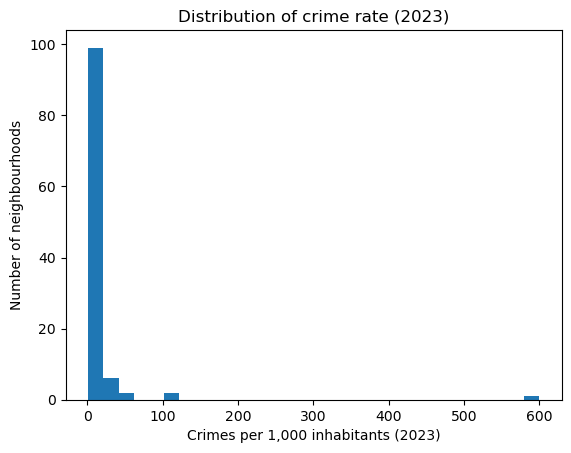

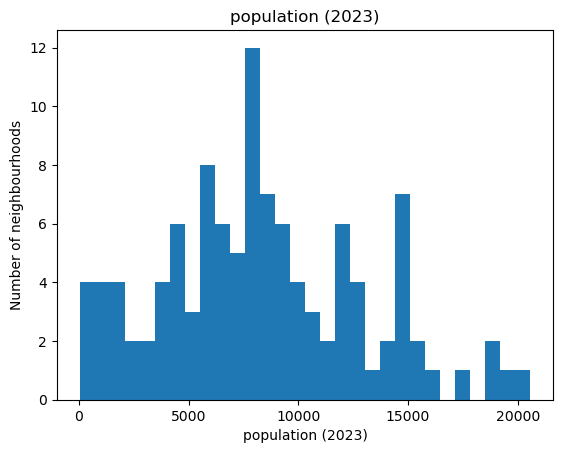

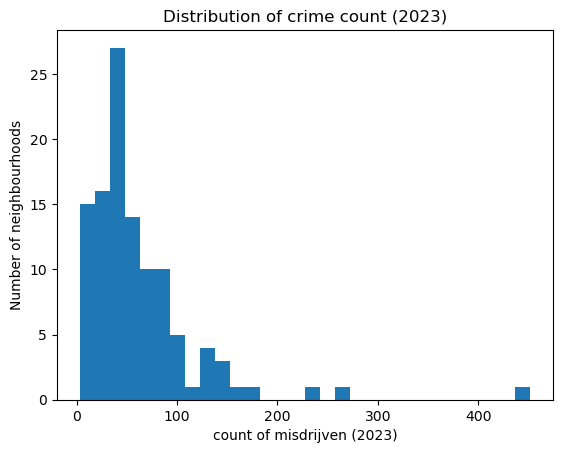

In [78]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(total_final_df["Misdrijven_per_1000_inwoners"], bins=30)
plt.xlabel("Crimes per 1,000 inhabitants (2023)")
plt.ylabel("Number of neighbourhoods")
plt.title("Distribution of crime rate (2023)")
plt.show()  #crimes heel raar verdeeld onderzoeken

plt.figure()
plt.hist(total_final_df["inwoners"], bins=30)
plt.xlabel("population (2023)")
plt.ylabel("Number of neighbourhoods")
plt.title("population (2023)")
plt.show()  

plt.figure()
plt.hist(total_final_df["Totaal misdrijven"], bins=30)
plt.xlabel("count of misdrijven (2023)")
plt.ylabel("Number of neighbourhoods")
plt.title("Distribution of crime count (2023)")
plt.show() 

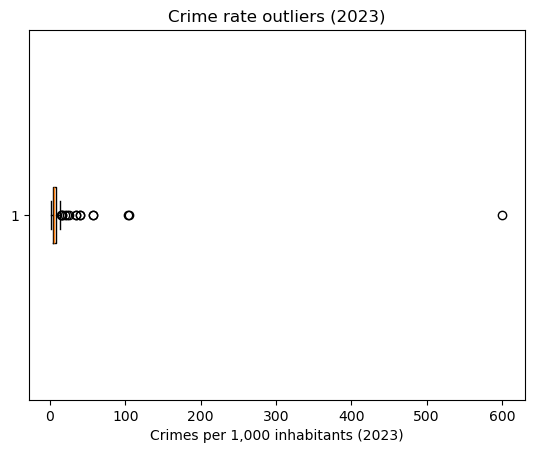

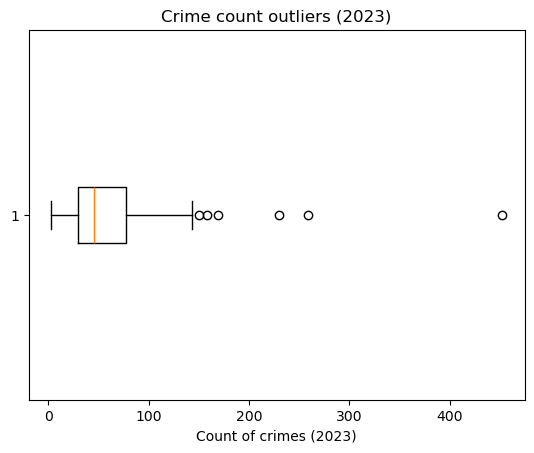

In [86]:
plt.figure()
plt.boxplot(total_final_df["Misdrijven_per_1000_inwoners"], vert=False)
plt.xlabel("Crimes per 1,000 inhabitants (2023)")
plt.title("Crime rate outliers (2023)")
plt.show() 

plt.figure()
plt.boxplot(total_final_df["Totaal misdrijven"], vert=False)
plt.xlabel("Count of crimes (2023)")
plt.title("Crime count outliers (2023)")
plt.show()

In [88]:
total_final_df.sort_values("Misdrijven_per_1000_inwoners", ascending=False)[
    ["wijkcode", "Misdrijven_per_1000_inwoners", "inwoners", "Totaal misdrijven", 'wijknaam']
].head(10) #so wierd boxplot caused by small populations causing huge ratios, so we have to do in the sensitivity analysis maybe  
# a version with only wijken with more than 1000 inhibitants

,wijkcode,Misdrijven_per_1000_inwoners,inwoners,Totaal misdrijven,wijknaam
10,WK0363BA,600.0,35,21.0,Havens-West
3,WK0363AD,104.267589,4335,452.0,Burgwallen-Nieuwe Zijde
32,WK0363FA,103.797468,1185,123.0,Sloterdijk Nieuw-West
12,WK0363EA,57.575758,660,38.0,Sloterdijk-West
4,WK0363AE,56.736035,4565,259.0,Burgwallen-Oude Zijde
6,WK0363AG,39.215686,5865,230.0,Grachtengordel-Zuid
98,WK0363TA,39.210155,3545,139.0,Amstel III/Bullewijk
91,WK0363NP,35.0,400,14.0,Noordelijke IJ-oevers-Oost
11,WK0363BB,33.846154,975,33.0,Coenhaven/Minervahaven
60,WK0363KP,25.07177,5225,131.0,Zuidas


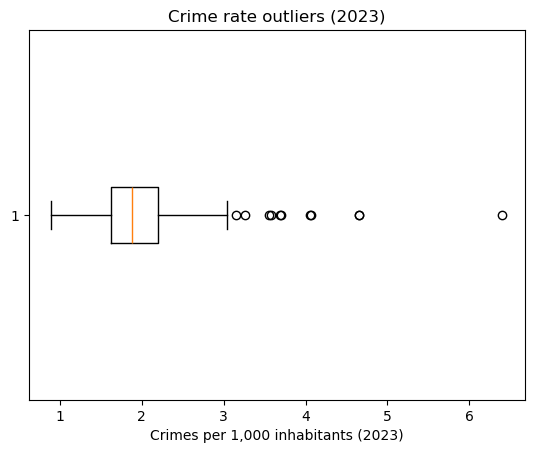

In [87]:
plt.figure()
plt.boxplot(np.log1p(total_final_df["Misdrijven_per_1000_inwoners"]), vert=False) #now the big ratios are less extreme
plt.xlabel("Crimes per 1,000 inhabitants (2023)")
plt.title("Crime rate outliers (2023)")
plt.show() 

“The crime rate (crimes per 1,000 residents) shows a strongly right-skewed distribution with a small number of extreme outliers. Inspection of the highest-rate districts reveals that these outliers are driven by very small resident populations (e.g., 21 crimes among 35 residents). This ‘small numbers’ issue makes rate estimates unstable for low-population districts, which we account for in subsequent analysis by using a log(1+rate) transformation / or excluding wijken below a population threshold in a robustness check).” VRAAG> WAT IS BETER 

#### Trees & lights distribution

In [91]:
feature_cols = ['Lights_per_km2', 'Trees_per_km2']

total_final_df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Lights_per_km2,110.0,1043.222072,435.436907,36.229272,777.218310,1121.172978,1354.553753,2152.5
Trees_per_km2,110.0,2233.538881,1196.847667,16.197183,1428.039514,2267.907560,2826.983217,6640.0


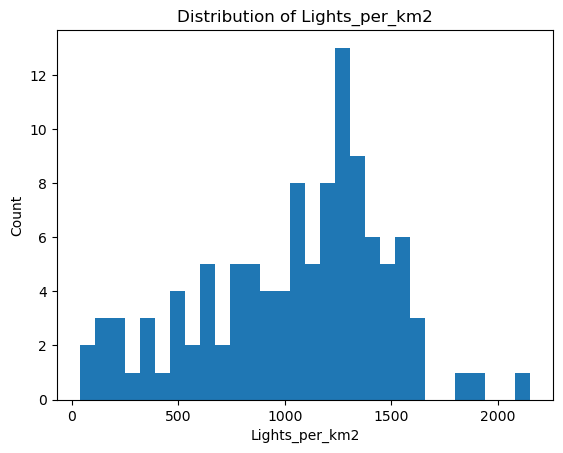

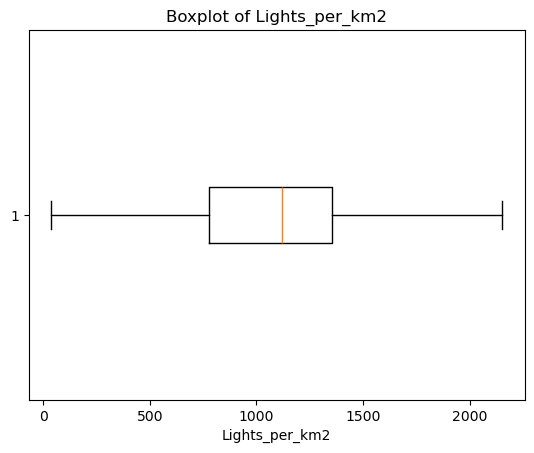

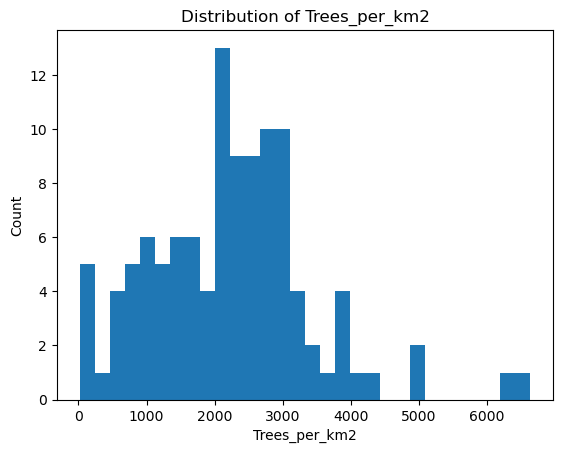

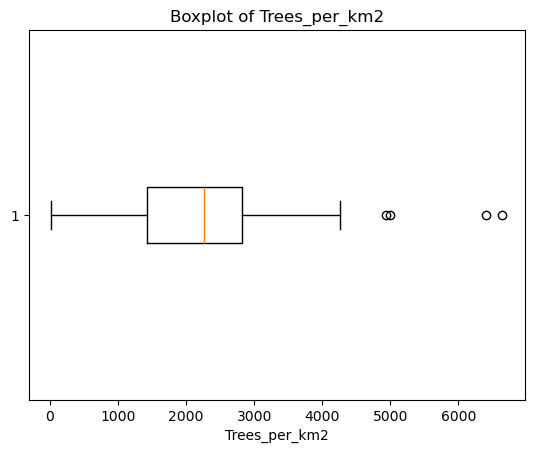

In [92]:
for col in feature_cols:
    x = total_final_df[col].dropna()

    plt.figure()
    plt.hist(x, bins=30)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure()
    plt.boxplot(x, vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.show()

#### Distances to

In [ ]:
#groups zijn al sterk onderbouwt op logica nog ff checken hoe correlatie is
target = "Misdrijven_per_1000_inwoners"

group_corr_summary = []

for gname, cols in groups.items():
    X = total_final_df[cols].copy()

    
    if len(cols) >= 2:
        c = X.corr(method="spearman")   spearman = robuuster bij non-lineair
        # gemiddelde abs correlatie zonder diagonaal
        mean_abs_corr = (c.abs().values.sum() - len(cols)) / (len(cols)*(len(cols)-1))
    else:
        mean_abs_corr = None

    group_corr_summary.append({
        "group": gname,
        "n_vars": len(cols),
        "mean_abs_spearman_within_group": None if mean_abs_corr is None else round(mean_abs_corr, 3)
    })

pd.DataFrame(group_corr_summary).sort_values("mean_abs_spearman_within_group", ascending=False) 

#0.4-0.7 = nice choerent group, rest is more broad 
#so overall nice coherent groups, others less but meaningfull

,group,n_vars,mean_abs_spearman_within_group
0,nightlife,6,0.737
2,retail_daily,3,0.633
3,education_youth,6,0.469
5,emergency_health,6,0.378
4,culture_sport_public,6,0.373
1,mobility,3,0.233


To validate our facility groupings, we computed the mean absolute Spearman correlation among the distance variables within each group. Nightlife and retail groups show high within-group coherence (0.74 and 0.63), while mobility is lower (0.23), indicating it captures a broader, multi-faceted accessibility dimension

In [104]:
min_cols  = [f"min_dist_{g}"  for g in groups.keys()]
mean_cols = [f"mean_dist_{g}" for g in groups.keys()]

rows = []
for g, cmin, cmean in zip(groups.keys(), min_cols, mean_cols):
    rows.append({
        "group": g,
        "spearman_min_vs_crime": total_final_df[cmin].corr(total_final_df[target], method="spearman"),
        "spearman_mean_vs_crime": total_final_df[cmean].corr(total_final_df[target], method="spearman"),
        "corr_min_vs_mean": total_final_df[cmin].corr(total_final_df[cmean], method="spearman"),
    })

comp = pd.DataFrame(rows)
comp[["spearman_min_vs_crime","spearman_mean_vs_crime","corr_min_vs_mean"]] = comp[
    ["spearman_min_vs_crime","spearman_mean_vs_crime","corr_min_vs_mean"]
].round(3)

comp 

#lees hier de richting van de relatie dus distance nightlife omlaag = crime omhoog, en hoe hoger hoe sterker  
#corr onderling tussen mean en min if high number they tell almost the same otherwise different so choice is important 

#moet dit nog specefieker? mag ik nu mean kiezen voor consistentie en over het algemeen beter

,group,spearman_min_vs_crime,spearman_mean_vs_crime,corr_min_vs_mean
0,nightlife,-0.372,-0.452,0.827
1,mobility,0.076,-0.164,0.658
2,retail_daily,-0.257,-0.233,0.782
3,education_youth,0.146,-0.079,0.495
4,culture_sport_public,-0.222,-0.379,0.644
5,emergency_health,-0.088,-0.239,0.385


Seeing what the relationships with crime look like

In [ ]:
#data to work with
target = "Misdrijven_per_1000_inwoners"

facility_mean_cols = [
    "mean_dist_nightlife",
    "mean_dist_mobility",
    "mean_dist_retail_daily",
    "mean_dist_education_youth",
    "mean_dist_culture_sport_public",
    "mean_dist_emergency_health",
]

feature_cols = ["Trees_per_km2", "Lights_per_km2"] + facility_mean_cols

df_model = total_final_df[["wijkcode", target] + feature_cols].dropna().copy()


df_model["log_crime_rate"] = np.log1p(df_model[target]) 
df_model.head()

,wijkcode,Misdrijven_per_1000_inwoners,Trees_per_km2,Lights_per_km2,mean_dist_nightlife,mean_dist_mobility,mean_dist_retail_daily,mean_dist_education_youth,mean_dist_culture_sport_public,mean_dist_emergency_health,log_crime_rate
0,WK0363AA,7.991242,1040.740741,1092.592593,0.783333,2.200000,0.466667,0.600000,2.400000,2.350000,2.196251
1,WK0363AB,7.674597,1274.736842,1400.000000,0.566667,2.600000,0.600000,0.633333,2.183333,1.783333,2.160399
2,WK0363AC,13.971147,1396.491228,1166.666667,0.566667,2.400000,0.500000,0.783333,2.183333,1.866667,2.706125
3,WK0363AD,104.267589,613.698630,1235.616438,0.566667,2.333333,0.366667,1.150000,2.216667,1.850000,4.656506
4,WK0363AE,56.736035,1057.500000,2152.500000,0.616667,2.200000,0.366667,1.283333,1.950000,1.733333,4.055882


In [ ]:
corr = pd.DataFrame({
    "spearman_vs_crime": [df_model[c].corr(df_model[target], method="spearman") for c in feature_cols],
    "pearson_vs_crime":  [df_model[c].corr(df_model[target], method="pearson")  for c in feature_cols],
}, index=feature_cols).round(3).sort_values("spearman_vs_crime")

corr 

#pearson zegt of het rechte lijn verband heeft, spearman of het rangordeverband (of het onver algemeen ook groter wordt) heeft (als ze heel anders zijn dan vaak geen lineair verband (hoe hoger hoe beter))

,spearman_vs_crime,pearson_vs_crime
mean_dist_nightlife,-0.452,0.143
mean_dist_culture_sport_public,-0.379,0.218
mean_dist_emergency_health,-0.239,0.238
mean_dist_retail_daily,-0.233,0.391
Trees_per_km2,-0.195,-0.251
mean_dist_mobility,-0.164,-0.059
mean_dist_education_youth,-0.079,0.548
Lights_per_km2,-0.056,-0.226


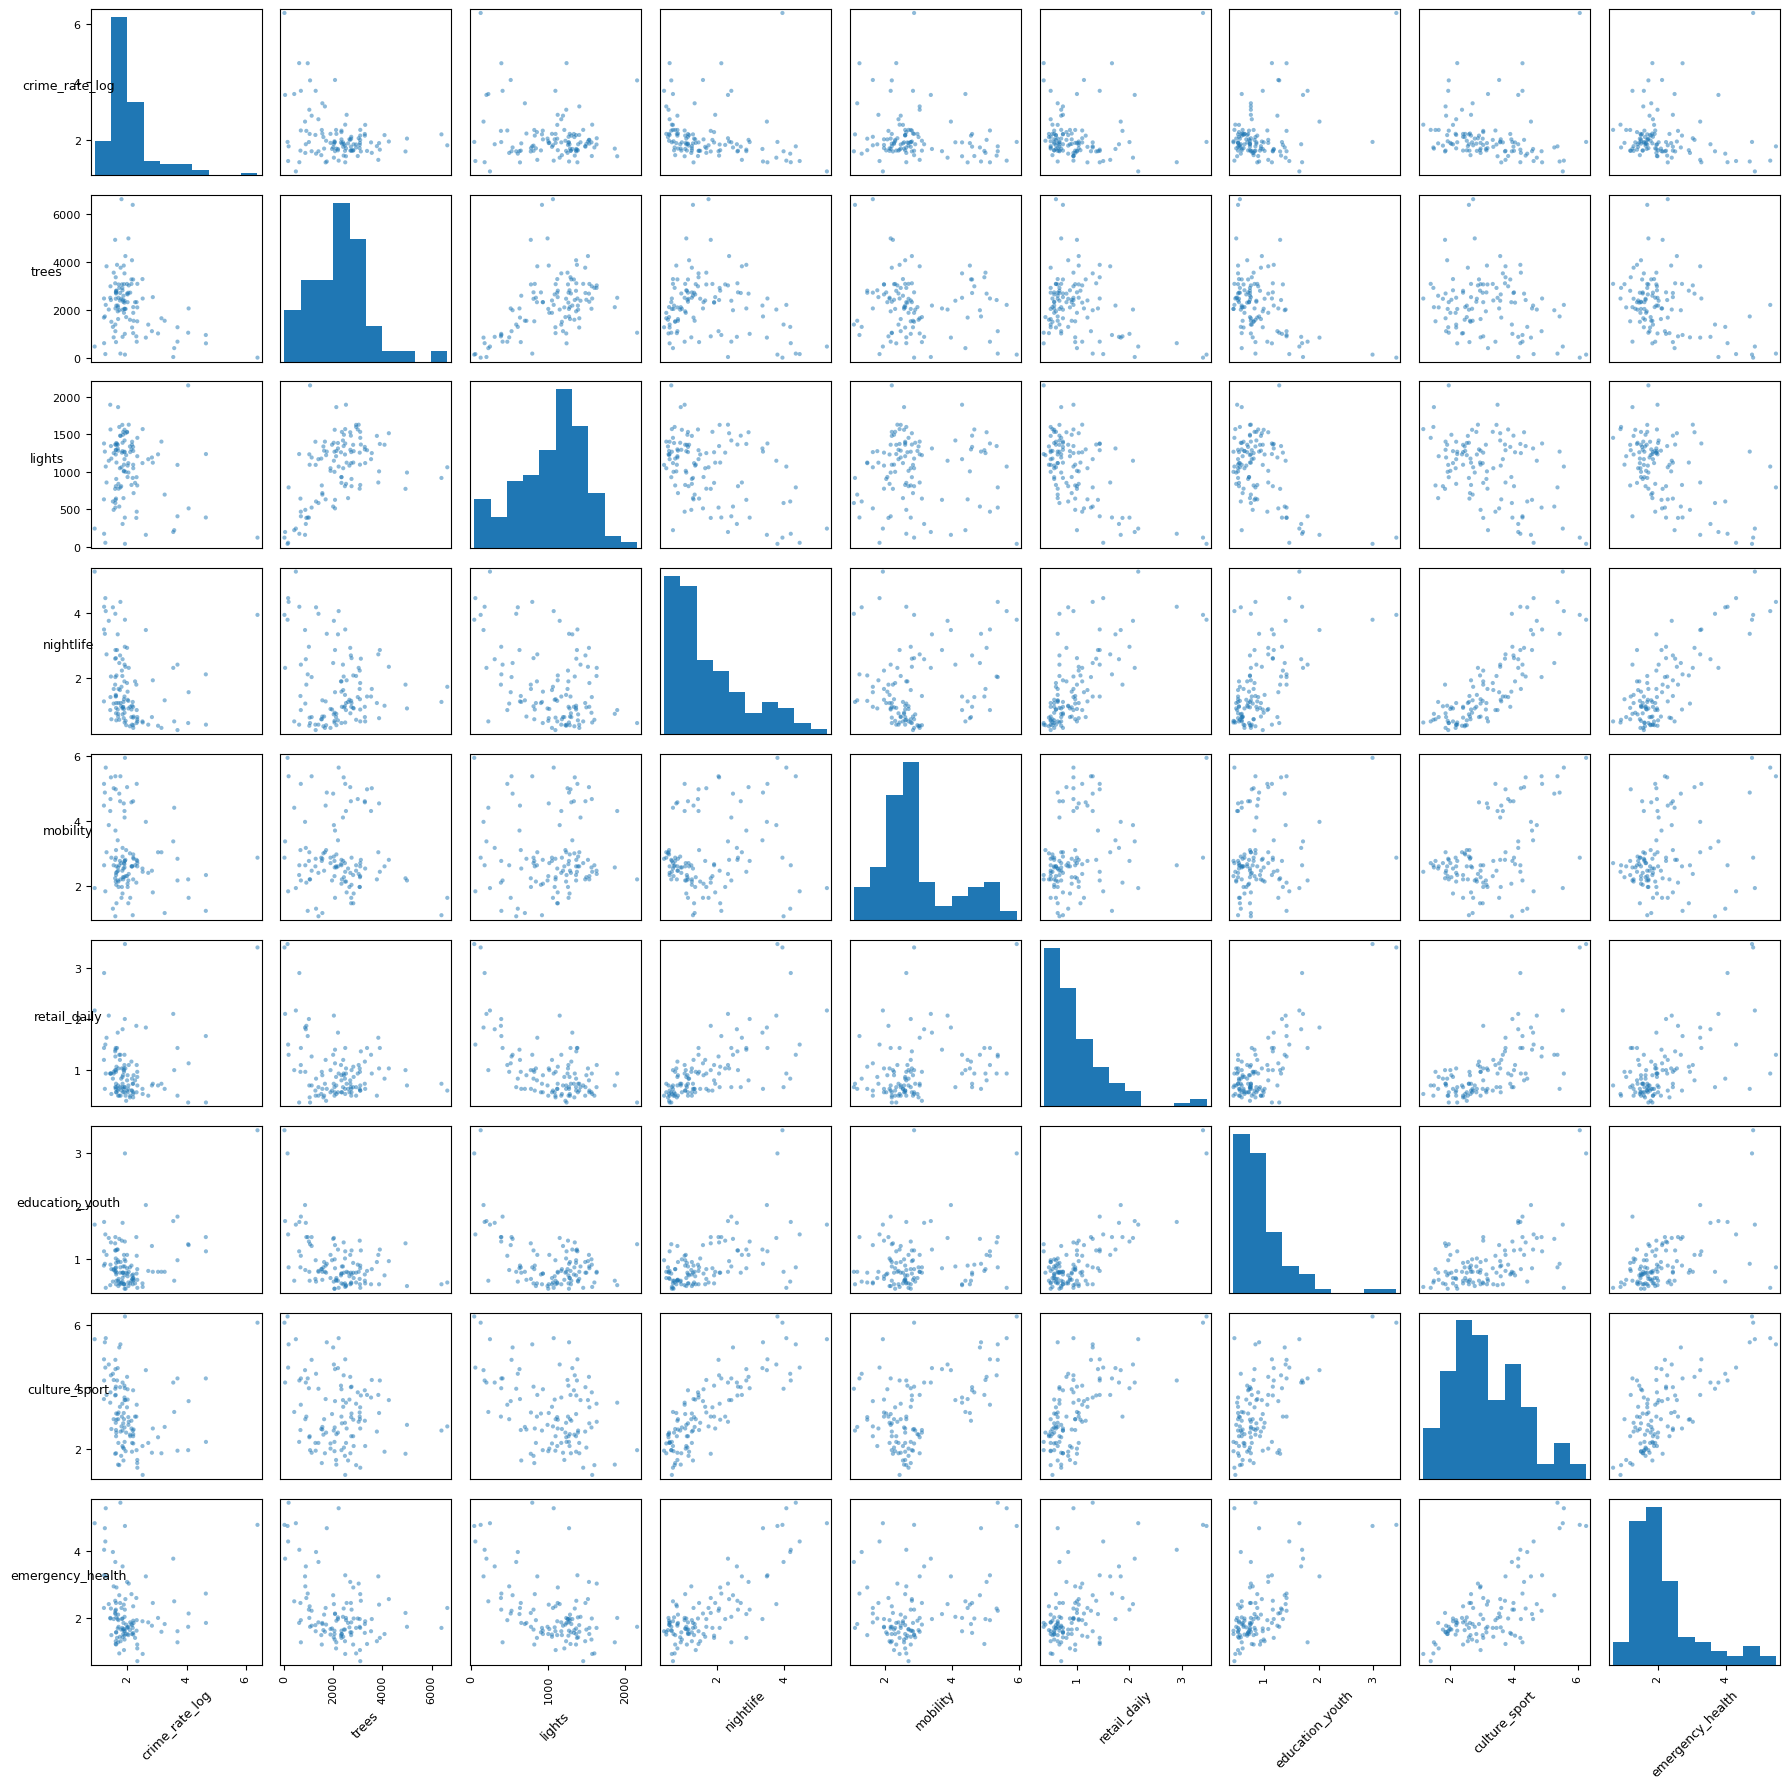

In [113]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# kies kolommen die je wil plotten
cols = [
    "log_crime_rate",
    "Trees_per_km2",
    "Lights_per_km2",
    "mean_dist_nightlife",
    "mean_dist_mobility",
    "mean_dist_retail_daily",
    "mean_dist_education_youth",
    "mean_dist_culture_sport_public",
    "mean_dist_emergency_health",
]

# mapping van oude -> nieuwe namen
rename_map = {
    "log_crime_rate": "crime_rate_log",
    "Trees_per_km2": "trees",
    "Lights_per_km2": "lights",
    "mean_dist_nightlife": "nightlife",
    "mean_dist_mobility": "mobility",
    "mean_dist_retail_daily": "retail_daily",
    "mean_dist_education_youth": "education_youth",
    "mean_dist_culture_sport_public": "culture_sport",
    "mean_dist_emergency_health": "emergency_health",
}

df_plot = df_model[cols].dropna().rename(columns=rename_map).copy()

# (optioneel) filter om extreme rate outliers te verminderen
# df_plot = total_final_df[total_final_df["inwoners"] > 500][cols].dropna().rename(columns=rename_map).copy()

axes = scatter_matrix(df_plot, figsize=(18, 18), alpha=0.5, diagonal="hist")

# labels leesbaar maken
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(45)
    ax.yaxis.label.set_rotation(0)
    ax.xaxis.label.set_fontsize(9)
    ax.yaxis.label.set_fontsize(9)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Kopie + (optioneel) filter voor stabielere rates
df = total_final_df.copy()
# df = df[df["inwoners"] > 500].copy()

# 2) Log target maken (zodat outliers niet alles slopen)
df["crime_rate_log"] = np.log1p(df["Misdrijven_per_1000_inwoners"])

# 3) Kolommen selecteren + hernoemen naar korte labels
cols = [
    "crime_rate_log",
    "Trees_per_km2",
    "Lights_per_km2",
    "mean_dist_nightlife",
    "mean_dist_mobility",
    "mean_dist_retail_daily",
    "mean_dist_education_youth",
    "mean_dist_culture_sport_public",
    "mean_dist_emergency_health",
]

rename_map = {
    "crime_rate_log": "crime_rate_log",
    "Trees_per_km2": "trees",
    "Lights_per_km2": "lights",
    "mean_dist_nightlife": "nightlife",
    "mean_dist_mobility": "mobility",
    "mean_dist_retail_daily": "retail_daily",
    "mean_dist_education_youth": "education_youth",
    "mean_dist_culture_sport_public": "culture_sport",
    "mean_dist_emergency_health": "emergency_health",
}

df_plot = df[cols].dropna().rename(columns=rename_map)

# 4) Seaborn: fancy pairplot met regressielijn + CI band
sns.set_theme(style="whitegrid")

g = sns.pairplot(
    df_plot,
    kind="reg",                 # regressielijn in off-diagonal
    diag_kind="kde",            # mooie diagonaal (kan ook "hist")
    plot_kws={"scatter_kws": {"s": 20, "alpha": 0.7},
              "line_kws": {"linewidth": 2}},
    height=2.0,
    corner=False                # True = alleen lower triangle (minder druk)
)

g.fig.suptitle("Pairplot with regression lines (crime_rate_log + features)", y=1.02)
plt.show()


A scatterplot matrix of the log-transformed crime rate and design features shows that proximity to nightlife, retail, and cultural amenities is associated with higher crime rates (negative relationship between distance and crime). Tree density shows a weaker negative association with crime, while streetlight density exhibits little clear monotone pattern. Several accessibility variables are strongly correlated with each other, indicating that central neighbourhoods tend to be close to multiple amenities, which may introduce collinearity in regression-based models

C:\Users\Emma Hendriks\AppData\Local\Temp\ipykernel_4128\2817269525.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")[ycol].mean()
C:\Users\Emma Hendriks\AppData\Local\Temp\ipykernel_4128\2817269525.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")[ycol].mean()
C:\Users\Emma Hendriks\AppData\Local\Temp\ipykernel_4128\2817269525.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

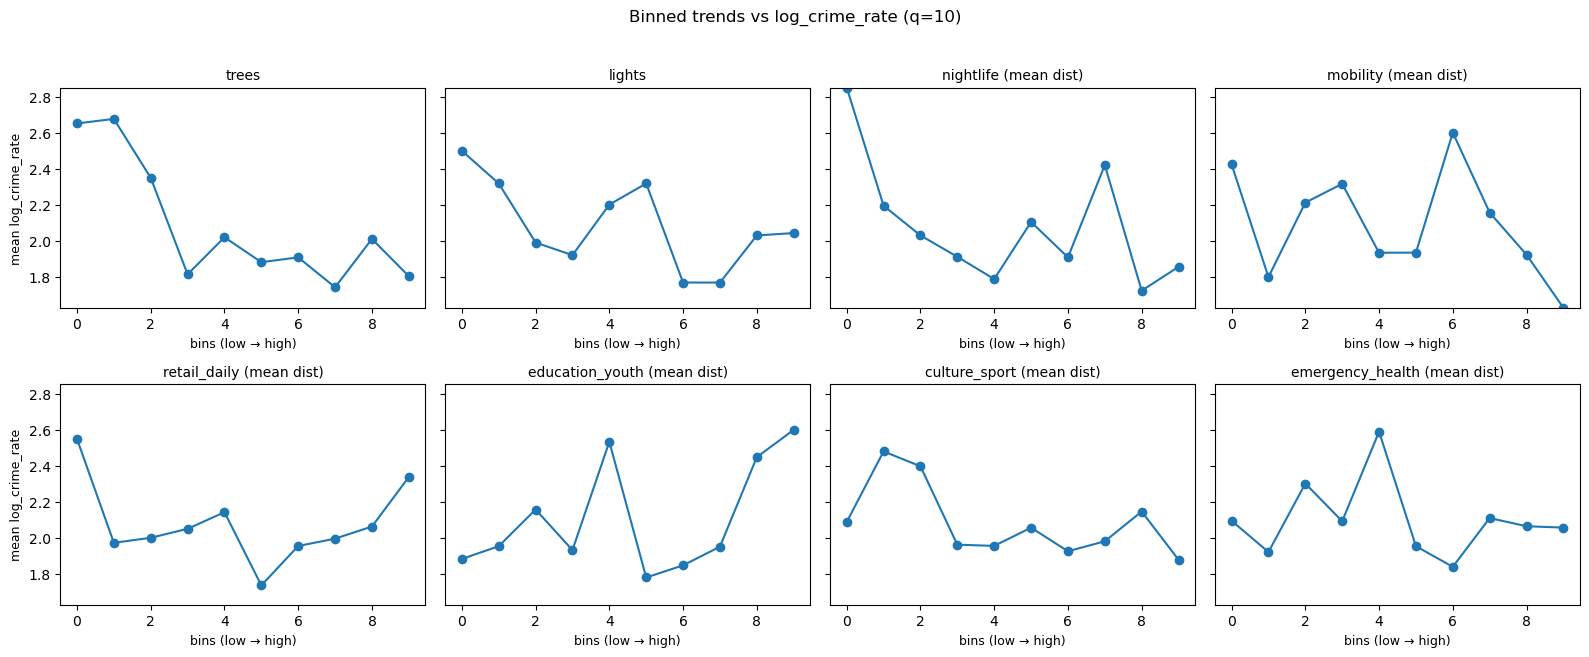

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = total_final_df.copy()

# Target (aanrader: log voor stabiliteit)
df["log_crime_rate"] = np.log1p(df["Misdrijven_per_1000_inwoners"])
target = "log_crime_rate"  # of "Misdrijven_per_1000_inwoners"

# (optioneel) filter voor stabielere rates
# df = df[df["inwoners"] > 500].copy()

feature_cols = [
    "Trees_per_km2",
    "Lights_per_km2",
    "mean_dist_nightlife",
    "mean_dist_mobility",
    "mean_dist_retail_daily",
    "mean_dist_education_youth",
    "mean_dist_culture_sport_public",
    "mean_dist_emergency_health",
]

pretty = {
    "Trees_per_km2": "trees",
    "Lights_per_km2": "lights",
    "mean_dist_nightlife": "nightlife (mean dist)",
    "mean_dist_mobility": "mobility (mean dist)",
    "mean_dist_retail_daily": "retail_daily (mean dist)",
    "mean_dist_education_youth": "education_youth (mean dist)",
    "mean_dist_culture_sport_public": "culture_sport (mean dist)",
    "mean_dist_emergency_health": "emergency_health (mean dist)",
}

def binned_means(df, xcol, ycol, q=10):
    tmp = df[[xcol, ycol]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[xcol], q=q, duplicates="drop")
    g = tmp.groupby("bin")[ycol].mean()
    return g.values  # array van means per bin

# Precompute y-limits (consistent y-as over alle subplots)
all_means = []
for col in feature_cols:
    all_means.extend(list(binned_means(df, col, target, q=10)))
ymin, ymax = np.nanmin(all_means), np.nanmax(all_means)

# Grid instellen
n = len(feature_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), sharey=True)
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    means = binned_means(df, col, target, q=10)

    ax.plot(range(len(means)), means, marker="o")
    ax.set_title(pretty.get(col, col), fontsize=10)
    ax.set_xlabel("bins (low → high)", fontsize=9)
    if i % ncols == 0:
        ax.set_ylabel(f"mean {target}", fontsize=9)

    ax.set_ylim(ymin, ymax)

# lege assen weg voor als grid groter is dan aantal features
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Binned trends vs {target} (q=10)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
